# Experiment No. 4
## Advanced Data Visualization using Matplotlib and Seaborn
* **Name:** Akshit Negi
* **Course & Branch:** B.TECH CSE
* **CUID:** CU24250214
* **SEM & Section:** 5th SEM , "B"

**Aim:** To create and analyze various data visualizations using Python libraries such as Matplotlib and Seaborn in order to identify trends, patterns, correlations, and insights from real-world datasets.

**Datasets used:**
- **Tips Dataset** (`seaborn.load_dataset('tips')`) — restaurant bill data with categorical variables (day, time, sex, smoker) and numerical variables (total_bill, tip, size). Used as the main dataset for categorical, distribution, outlier, relationship, and correlation charts.
- **Flights Dataset** (`seaborn.load_dataset('flights')`) — monthly airline passenger counts over time. Used specifically for the time-trend line chart.

Both load directly in Google Colab with no file upload required.

---

### Step 1: Select a real-world dataset

We use the **Tips Dataset** as the primary dataset for categorical, distribution, and relationship charts, and the **Flights Dataset** for the time-series trend chart.

In [1]:
import seaborn as sns

tips = sns.load_dataset('tips')
flights = sns.load_dataset('flights')

print("Tips dataset:")
display(tips.head())

print("\nFlights dataset:")
display(flights.head())

Tips dataset:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4



Flights dataset:


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


### Step 2: Import the required libraries and load the cleaned dataset

Import Pandas, Matplotlib, and Seaborn, and perform a basic check for missing values.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Missing values in tips dataset:\n", tips.isnull().sum())
print("\nMissing values in flights dataset:\n", flights.isnull().sum())
print("\nTips dataset shape:", tips.shape)
print("Flights dataset shape:", flights.shape)

Missing values in tips dataset:
 total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

Missing values in flights dataset:
 year          0
month         0
passengers    0
dtype: int64

Tips dataset shape: (244, 7)
Flights dataset shape: (144, 3)


### Step 3: Create bar charts to compare categorical variables

Compare the average total bill across different days of the week.

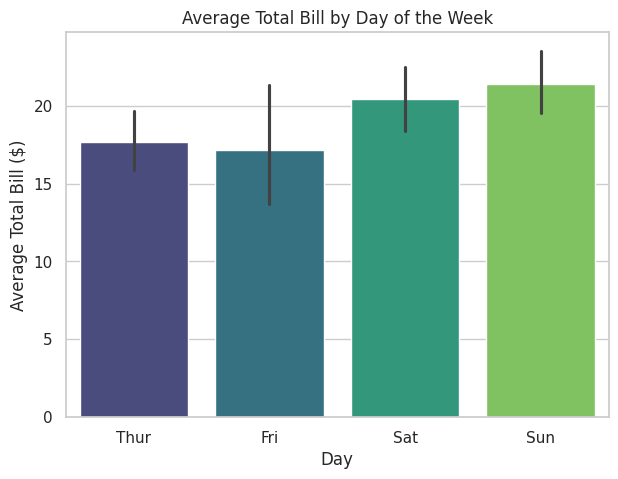

In [3]:
plt.figure(figsize=(7, 5))
sns.barplot(data=tips, x='day', y='total_bill', hue='day', palette='viridis', estimator=np.mean, legend=False)
plt.title("Average Total Bill by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Average Total Bill ($)")
plt.show()

### Step 4: Generate line charts to analyze trends over time

Analyze the trend in the number of airline passengers over the years using the Flights dataset.

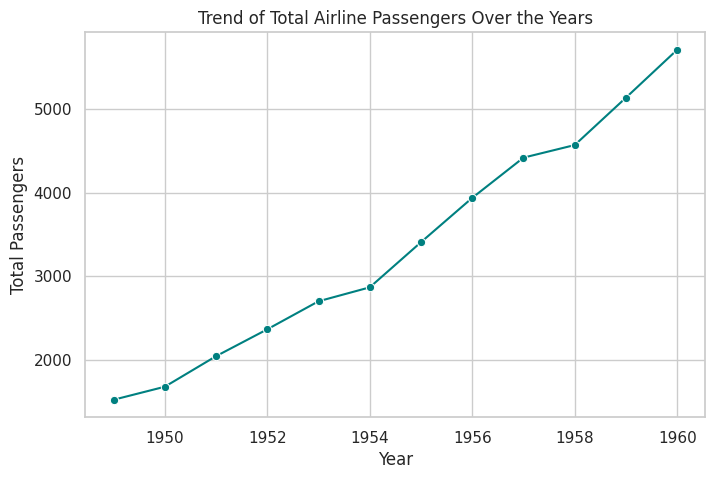

In [4]:
yearly_passengers = flights.groupby('year')['passengers'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(data=yearly_passengers, x='year', y='passengers', marker='o', color='teal')
plt.title("Trend of Total Airline Passengers Over the Years")
plt.xlabel("Year")
plt.ylabel("Total Passengers")
plt.show()

### Step 5: Plot histograms to study the distribution of numerical variables

Study the distribution of `total_bill` and `tip` amounts.

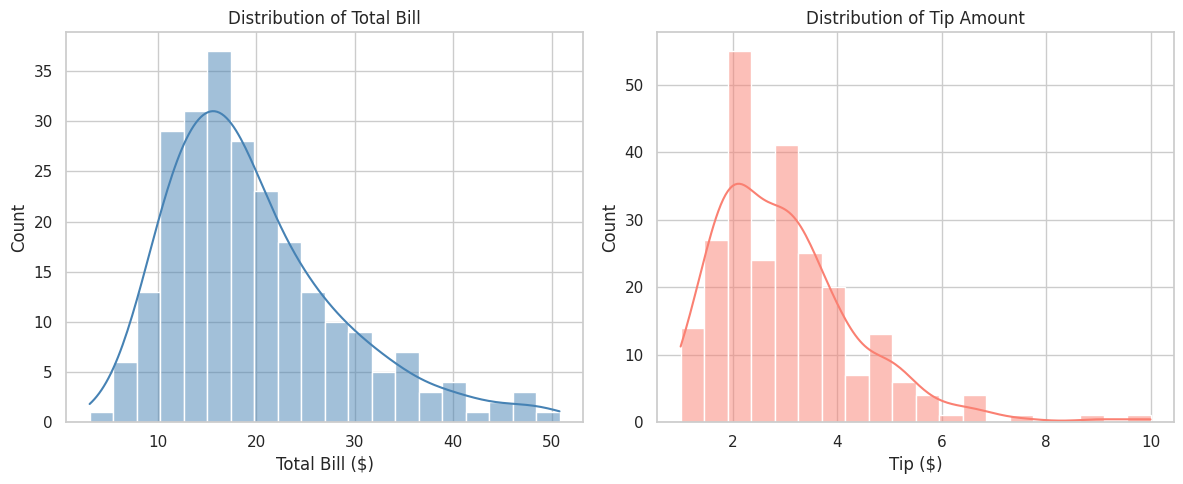

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(tips['total_bill'], bins=20, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title("Distribution of Total Bill")
axes[0].set_xlabel("Total Bill ($)")

sns.histplot(tips['tip'], bins=20, kde=True, color='salmon', ax=axes[1])
axes[1].set_title("Distribution of Tip Amount")
axes[1].set_xlabel("Tip ($)")

plt.tight_layout()
plt.show()

### Step 6: Create box plots to identify outliers and compare distributions

Compare the distribution of `total_bill` across different days, and identify outliers.

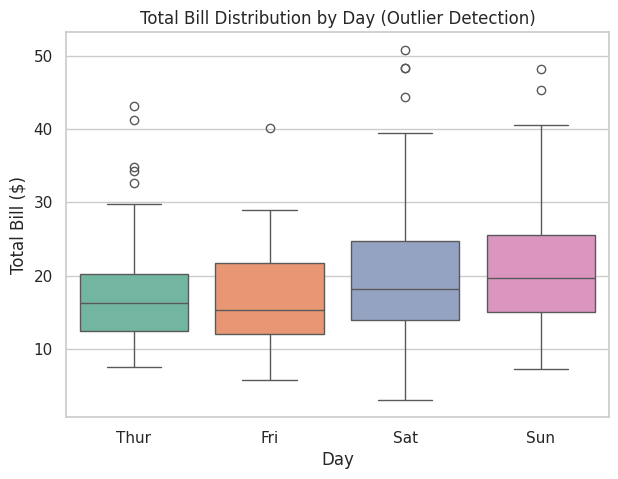

In [6]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=tips, x='day', y='total_bill', hue='day', palette='Set2', legend=False)
plt.title("Total Bill Distribution by Day (Outlier Detection)")
plt.xlabel("Day")
plt.ylabel("Total Bill ($)")
plt.show()

### Step 7: Generate scatter plots to analyze relationships between two numerical variables

Analyze the relationship between `total_bill` and `tip`.

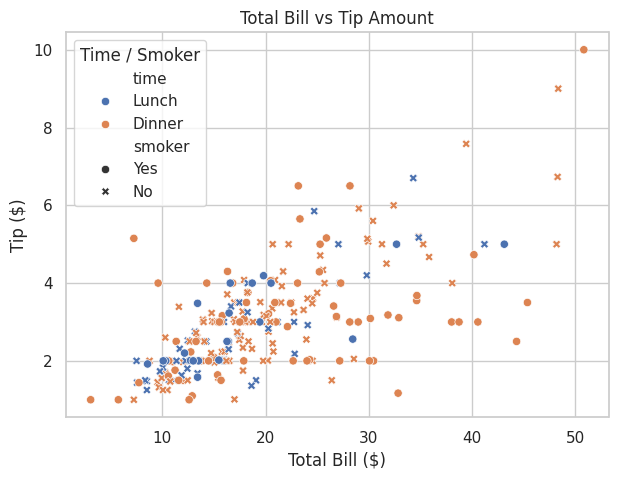

In [7]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time', style='smoker', palette='deep')
plt.title("Total Bill vs Tip Amount")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.legend(title="Time / Smoker")
plt.show()

### Step 8: Create a correlation heatmap

Visualize relationships among numerical features (`total_bill`, `tip`, `size`) using Seaborn.

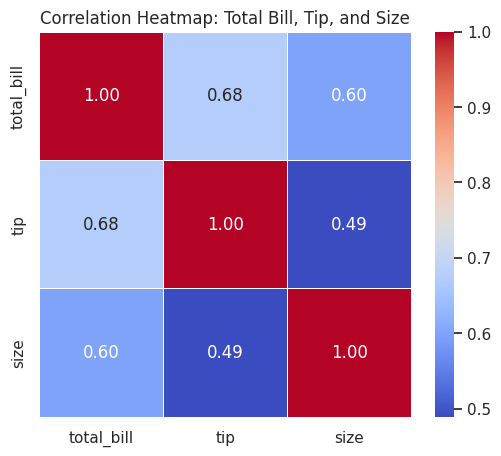

In [8]:
numeric_cols = tips[['total_bill', 'tip', 'size']]
corr_matrix = numeric_cols.corr(method='pearson')

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Total Bill, Tip, and Size")
plt.show()

### Step 9: Customize the visualizations

Improve readability by adding titles, axis labels, legends, annotations, and appropriate color palettes.

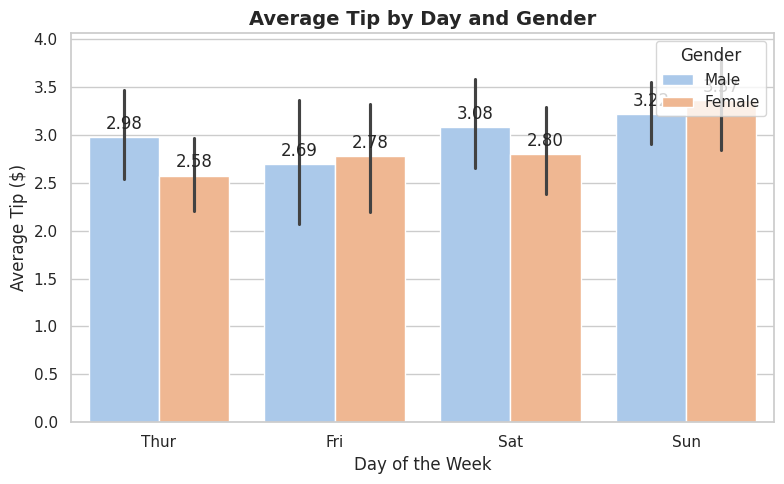

In [9]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=tips, x='day', y='tip', hue='sex', palette='pastel', estimator=np.mean)

ax.set_title("Average Tip by Day and Gender", fontsize=14, fontweight='bold')
ax.set_xlabel("Day of the Week", fontsize=12)
ax.set_ylabel("Average Tip ($)", fontsize=12)
ax.legend(title="Gender", loc='upper right')

# Annotate bar values
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

### Step 10: Interpret each visualization and summarize key insights

- **Bar chart:** Average total bill varies by day, with weekends typically showing higher spending, useful for staffing and promotion planning.
- **Line chart:** Airline passenger traffic shows a clear upward trend over the years, indicating consistent growth in demand.
- **Histograms:** Both `total_bill` and `tip` are right-skewed, meaning most transactions are of moderate value with a few high-value outliers.
- **Box plot:** Certain days show a wider spread and more outliers in total bill, indicating occasional very high-value orders.
- **Scatter plot:** There is a positive relationship between `total_bill` and `tip` — larger bills tend to receive larger tips.
- **Correlation heatmap:** `total_bill` and `tip` are strongly positively correlated, while `size` (party size) also positively correlates with both.
- **Customized chart:** Adding labels, legends, and annotations makes the average-tip-by-gender comparison immediately clear without needing to inspect raw numbers.

Overall, these visualizations reveal spending patterns, growth trends, distribution shapes, and relationships between variables — insights that directly support pricing, staffing, and marketing decisions.

---

## Questions

**Q1. Why is data visualization considered an essential component of data analytics?**

**Ans:** Data visualization converts raw, complex data into intuitive graphical form, making it easier and faster to identify trends, patterns, outliers, and relationships than by scanning numbers alone. It helps analysts and decision-makers quickly grasp insights, communicate findings effectively to non-technical stakeholders, and supports faster, more confident data-driven decisions.

**Q2. Differentiate between Matplotlib and Seaborn. Which library is more suitable for statistical visualizations and why?**

**Ans:** Matplotlib is a low-level, highly customizable plotting library that gives fine-grained control over every element of a chart but requires more code to produce polished, statistically informative plots. Seaborn is built on top of Matplotlib and provides high-level functions with attractive default styles, built-in statistical estimation (like confidence intervals, regression lines, and aggregation), and easy integration with Pandas DataFrames. Seaborn is generally more suitable for statistical visualizations because it can automatically compute and display statistical summaries (means, distributions, correlations) with far less code.

**Q3. Which type of chart would you choose to compare sales across different regions? Justify your answer.**

**Ans:** A bar chart is the most suitable choice for comparing sales across different regions because it clearly displays and compares discrete categorical values (regions) against a numerical measure (sales), making differences in magnitude easy to see at a glance.

**Q4. What information can be obtained from a histogram and a box plot?**

**Ans:** A histogram shows the frequency distribution of a numerical variable, revealing its shape (symmetric, skewed, bimodal), central tendency, and spread. A box plot summarizes a distribution using five key statistics — minimum, first quartile (Q1), median, third quartile (Q3), and maximum — and clearly highlights outliers as points beyond the whiskers, while also making it easy to compare spread and central tendency across multiple categories.

**Q5. Explain the purpose of a scatter plot. How does it help in identifying relationships between variables?**

**Ans:** A scatter plot displays individual data points for two numerical variables on the X and Y axes, allowing visual inspection of the relationship between them. It helps identify whether a relationship is positive, negative, or absent, whether the relationship is linear or non-linear, and whether there are clusters or outliers, making it a key tool before applying correlation or regression analysis.

**Q6. What is a correlation heatmap? How can it assist in feature selection for machine learning?**

**Ans:** A correlation heatmap is a color-coded matrix visualization that displays the pairwise Pearson correlation coefficients between numerical variables in a dataset. It assists in feature selection by quickly revealing which features are strongly correlated with the target variable (useful predictors) and which features are highly correlated with each other (redundant/multicollinear), helping analysts choose a more relevant and non-redundant set of features for a model.

**Q7. Why is chart customization (titles, labels, legends, colors) important in data visualization?**

**Ans:** Customization ensures a chart is self-explanatory and unambiguous — titles state what the chart shows, axis labels clarify units and variables, legends distinguish categories or groups, and thoughtful color choices improve readability and highlight important patterns. Without proper customization, even a technically correct chart can be confusing or misleading to the viewer.

**Q8. What factors should be considered while selecting an appropriate visualization for a dataset?**

**Ans:** Key factors include: the type of data (categorical vs. numerical vs. time-series), the number of variables being compared (univariate, bivariate, multivariate), the analytical goal (comparison, distribution, relationship, composition, or trend), the size of the dataset, and the audience's familiarity with the chart type, ensuring the chosen visualization clearly and accurately conveys the intended insight.

**Q9. How can misleading visualizations affect business decision-making? Give a real-world example.**

**Ans:** Misleading visualizations — such as truncated Y-axes, inconsistent scales, cherry-picked time ranges, or inappropriate chart types — can exaggerate or hide trends, leading decision-makers to draw incorrect conclusions and make poor strategic choices. For example, a company might use a bar chart with a Y-axis that doesn't start at zero to make a small increase in sales look dramatically large, potentially leading executives to over-invest in a strategy that isn't actually performing as well as it appears.

**Q10. Explain how data visualization supports storytelling and business intelligence in organizations.**

**Ans:** Data visualization turns raw datasets into a coherent narrative by sequencing charts and dashboards that highlight key trends, comparisons, and outliers relevant to a business question. In business intelligence, interactive dashboards let stakeholders explore KPIs and trends in real time, enabling faster identification of opportunities or problems. This "data storytelling" makes complex analytical findings accessible to non-technical decision-makers, driving alignment and faster, evidence-based organizational decisions.